# DockingMT workflow profiling: retained 181L baseline

This notebook explores the **2026-10-02 measured baseline**, owned by
[DockingMT #28](https://github.com/uibcdf/dockingmt/issues/28).
The [measurement document](workflow_profiling.md) defines every phase and its limits.

Two routes were measured: molecular 181L inputs with automatic preparation,
and verified captured PDBQT inputs. Each has three enabled/disabled pairs,
measured in fresh interpreters with alternating order, seed=42 and cpu=1.
The original JSON reports are versioned alongside this notebook, including
all twelve samples, software versions, source/input hashes and units.

**Running all cells reads the retained evidence and draws figures.** It does
not run docking unless `RERUN` is explicitly changed in the final section.
Reading requires Jupyter/IPython and Matplotlib, plus this checkout for the
existing report summarizer. It does not import the scientific package or
require Vina or MolSysViewer. No notebook dependency is added to DockingMT.

This is performance evidence for an exploratory case whose chemistry remains
provisional. It does not qualify docking accuracy or establish a portable budget.

In [1]:
import json
import sys
from pathlib import Path

from IPython.display import Markdown, display

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'devtools/profile_workflow.py').is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError('Open this notebook from within the DockingMT checkout.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# The tool imports only the standard library until actual docking is requested.
from devtools.profile_workflow import _summarize

DATA = ROOT / 'devguide/validation/data/workflow_profiling'
DATA_LABEL = 'Retained 2026-10-02 baseline'
REPORT_FILES = {
    'Molecular 181L': DATA / '181l_molecular_2026-10-02.json',
    'Captured PDBQT': DATA / '181l_captured_pdbqt_2026-10-02.json',
}
reports = {name: json.loads(path.read_text()) for name, path in REPORT_FILES.items()}
for name, report in reports.items():
    assert report['schema_version'] == '1.0', name
    assert report['unit'] == 'second' and report['clock'] == 'perf_counter', name
    assert len(report['samples']) >= 2 and len(report['samples']) % 2 == 0, name
    assert all(sample['n_poses'] > 0 for sample in report['samples']), name

# Reuse the measured tool's summarizer; the original reports predate its
# execution-context flag, which is checked here from the original samples.
summaries = {name: _summarize(report['samples']) for name, report in reports.items()}
for name, summary in summaries.items():
    for field in ('scientific_outputs_match', 'input_identities_match',
                  'execution_contexts_match'):
        assert summary[field], f'{name}: {field}'
sample_count = sum(len(report['samples']) for report in reports.values())
print(f'{DATA_LABEL}: verified {sample_count} samples; outputs, inputs and contexts match within each route.')

Retained 2026-10-02 baseline: verified 12 samples; outputs, inputs and contexts match within each route.


## Recorded environment and source identity

The versions below describe the **measured environment**, not the current
notebook kernel. The editable DockingMT version string was stale; HEAD,
dirty-state flag and source SHA-256 identify the actual inspected code.
The two routes are checked independently: their input formats and source maps
differ, so their output hashes need not match one another.

In [2]:
for name, report in reports.items():
    sample = report['samples'][0]
    display(Markdown(f'### {name}'))
    print(json.dumps({field: sample[field] for field in (
        'environment', 'source_revision', 'profiler_sha256', 'input_identity',
    )}, indent=2))

### Molecular 181L

{
  "environment": {
    "platform": "Linux-7.0.0-28-generic-x86_64-with-glibc2.39",
    "python": "3.13.14",
    "versions": {
      "argdigest": "0.12.1+7.ga2edfe9",
      "depdigest": "0.10.1+15.g78a9106",
      "dockingmt": "0.0.0+14.g25b6e0b.dirty",
      "molsysmt": "0.22.4+118.g03b318549.dirty",
      "numpy": "2.4.6",
      "pyunitwizard": "0.27.0",
      "smonitor": "0.18.0+1.gb308ee0",
      "vina": "1.2.7"
    }
  },
  "source_revision": {
    "code_sha256": "5db4db57cb25294c5e2865fbced654adcfbdbcc59aad5b3a51050abb7816597c",
    "git_head": "df77c1789c547275981678c720d59684f701e1c1",
    "worktree_dirty": true
  },
  "profiler_sha256": "edac408de66f6783944503ecea04d8ab9e580c3c5630b63e18c7d86276a5e4a9",
  "input_identity": {
    "source_sha256": "77018feaaa65bb22dea47c784e8c059b0ccc09cd6dc7442b79cce83f3170985f"
  }
}


### Captured PDBQT

{
  "environment": {
    "platform": "Linux-7.0.0-28-generic-x86_64-with-glibc2.39",
    "python": "3.13.14",
    "versions": {
      "argdigest": "0.12.1+7.ga2edfe9",
      "depdigest": "0.10.1+15.g78a9106",
      "dockingmt": "0.0.0+14.g25b6e0b.dirty",
      "molsysmt": "0.22.4+118.g03b318549.dirty",
      "numpy": "2.4.6",
      "pyunitwizard": "0.27.0",
      "smonitor": "0.18.0+1.gb308ee0",
      "vina": "1.2.7"
    }
  },
  "source_revision": {
    "code_sha256": "5db4db57cb25294c5e2865fbced654adcfbdbcc59aad5b3a51050abb7816597c",
    "git_head": "df77c1789c547275981678c720d59684f701e1c1",
    "worktree_dirty": true
  },
  "profiler_sha256": "edac408de66f6783944503ecea04d8ab9e580c3c5630b63e18c7d86276a5e4a9",
  "input_identity": {
    "manifest_sha256": "44a7c23fa4a6c04cb3ee1a4ced7668b75090d79e7dc5f0426b7540f9ae43e194"
  }
}


## Workflow measurements

Wall-clock seconds; three samples per mode. Import includes MolSysMT,
PyUnitWizard and DockingMT. Input normalization includes problem/protocol
construction and identity bookkeeping; the captured route also loads and
validates its manifest. Interpreter startup and report bookkeeping are excluded.
File writes do not `fsync`. OS caches are retained.

In [3]:
def show_table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |',
             '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(map(str, row)) + ' |' for row in rows)
    display(Markdown('\n'.join(lines)))

modes = ('disabled', 'enabled')
routes = list(summaries)
outer_names = ['import', 'input_normalization', 'dock_call',
               'result_export', 'json_encoding', 'file_write']
show_table(
    ['Measurement (s)'] + [f'{route} / {mode}' for route in routes for mode in modes],
    [[phase] + [f"{summaries[route]['measurement_medians'][mode][phase]:.6f}"
                for route in routes for mode in modes] for phase in outer_names],
)

| Measurement (s) | Molecular 181L / disabled | Molecular 181L / enabled | Captured PDBQT / disabled | Captured PDBQT / enabled |
| --- | --- | --- | --- | --- |
| import | 0.461827 | 0.472851 | 0.454953 | 0.453780 |
| input_normalization | 5.966312 | 5.498096 | 0.010756 | 0.010935 |
| dock_call | 1.333756 | 1.300083 | 1.028671 | 1.008789 |
| result_export | 0.001502 | 0.001449 | 0.000368 | 0.000366 |
| json_encoding | 0.000814 | 0.000859 | 0.000869 | 0.000946 |
| file_write | 0.000195 | 0.000162 | 0.000195 | 0.000206 |

## Adapter phase measurements

Profiling-enabled medians in seconds. These phases are **inside** `dock_call`;
do not add the phase table to the workflow table. Existing native elapsed time
also overlaps `native_docking`. Individual phase medians need not sum to the
median adapter total. The [phase definitions](workflow_profiling.md#measurement-boundaries)
describe the exact attribution boundaries.

In [4]:
phase_names = ['validation', 'search_domain_projection', 'preparation',
               'backend_import', 'input_projection', 'engine_setup',
               'affinity_maps', 'native_docking', 'result_normalization', 'cleanup']
show_table(
    ['Adapter phase (s)'] + routes,
    [[phase] + [f"{summaries[route]['adapter_phase_medians'][phase]:.6f}"
                for route in routes] for phase in phase_names],
)

| Adapter phase (s) | Molecular 181L | Captured PDBQT |
| --- | --- | --- |
| validation | 0.000084 | 0.000077 |
| search_domain_projection | 0.000433 | 0.000472 |
| preparation | 0.273936 | 0.000015 |
| backend_import | 0.003198 | 0.002988 |
| input_projection | 0.008094 | 0.001302 |
| engine_setup | 0.031056 | 0.029962 |
| affinity_maps | 0.652852 | 0.650054 |
| native_docking | 0.326389 | 0.321114 |
| result_normalization | 0.001562 | 0.001499 |
| cleanup | 0.000104 | 0.000120 |

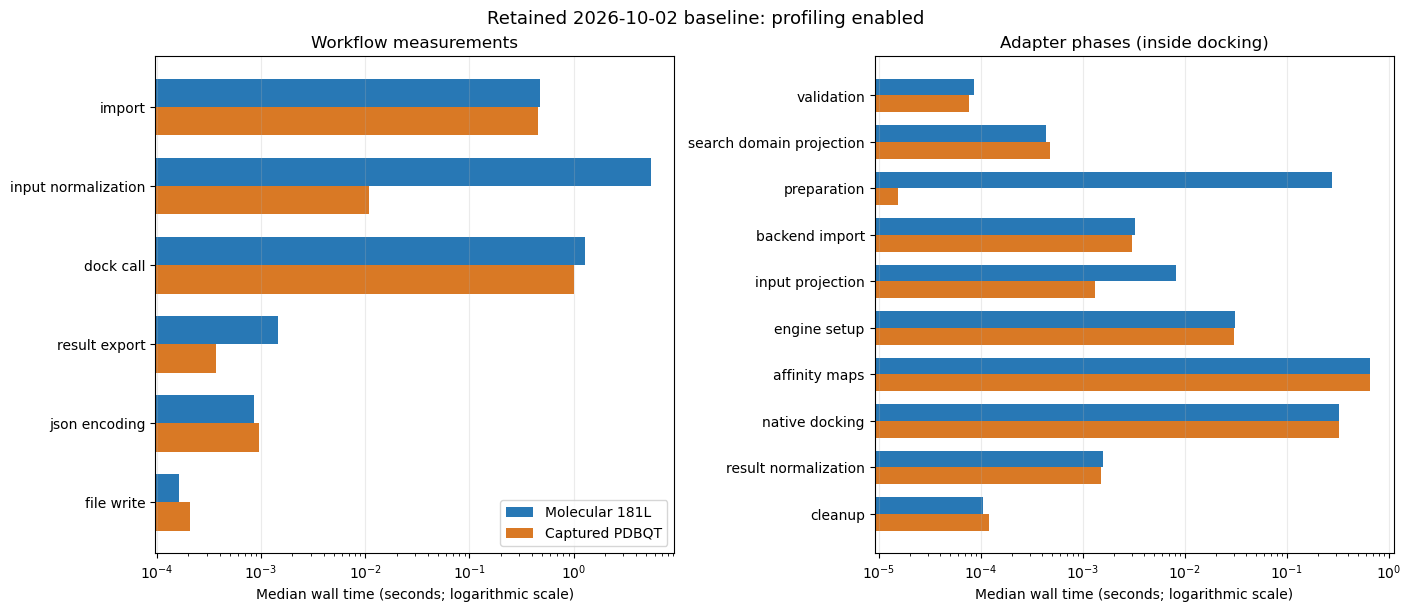

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout='constrained')
colors = ('#2878b5', '#d97925')
for ax, names, kind, title in (
    (axes[0], outer_names, 'outer', 'Workflow measurements'),
    (axes[1], phase_names, 'adapter', 'Adapter phases (inside docking)'),
):
    for index, route in enumerate(routes):
        values = (
            summaries[route]['measurement_medians']['enabled']
            if kind == 'outer' else summaries[route]['adapter_phase_medians']
        )
        ax.barh([position + (index - 0.5) * 0.36 for position in range(len(names))],
                [values[name] for name in names], height=0.36,
                label=route, color=colors[index])
    ax.set_yticks(range(len(names)), [name.replace('_', ' ') for name in names])
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_xlabel('Median wall time (seconds; logarithmic scale)')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
axes[0].legend()
fig.suptitle(f'{DATA_LABEL}: profiling enabled', fontsize=13)
plt.show()

## Variation and profiling cost

Negative enabled-minus-disabled median differences do **not** demonstrate a
speedup or bound the profiler's overhead. Inspect the original paired samples:
the variability is larger than any cost these measurements can resolve.
Disabled-path clock counts and exact output preservation are tested separately.

In [6]:
show_table(
    ['Route', 'Pair', 'First mode', 'First dock call (s)',
     'Second mode', 'Second dock call (s)'],
    [[route, pair // 2 + 1,
      'enabled' if samples[pair]['collect_timings'] else 'disabled',
      f"{samples[pair]['measurements']['dock_call']:.6f}",
      'enabled' if samples[pair + 1]['collect_timings'] else 'disabled',
      f"{samples[pair + 1]['measurements']['dock_call']:.6f}"]
     for route, report in reports.items()
     for samples in [report['samples']]
     for pair in range(0, len(samples), 2)],
)
for route, summary in summaries.items():
    delta = summary['dock_call_median_difference']
    print(f'{route}: enabled minus disabled median = {delta:+.6f} seconds')

| Route | Pair | First mode | First dock call (s) | Second mode | Second dock call (s) |
| --- | --- | --- | --- | --- | --- |
| Molecular 181L | 1 | disabled | 1.333756 | enabled | 1.300083 |
| Molecular 181L | 2 | enabled | 1.285159 | disabled | 1.320067 |
| Molecular 181L | 3 | disabled | 1.366023 | enabled | 1.404931 |
| Captured PDBQT | 1 | disabled | 1.046106 | enabled | 1.008789 |
| Captured PDBQT | 2 | enabled | 1.029100 | disabled | 1.002368 |
| Captured PDBQT | 3 | disabled | 1.028671 | enabled | 0.999279 |

Molecular 181L: enabled minus disabled median = -0.033674 seconds
Captured PDBQT: enabled minus disabled median = -0.019882 seconds


## Interpretation of this baseline

Molecular 181L problem construction/normalization dominates this workflow
(~5.5 s). Supplying captured PDBQT reduces the input step to ~11 ms and avoids
automatic molecular preparation. Within the adapter, affinity maps (~0.65 s)
dominate, followed by native search (~0.32 s); automatic preparation takes
~0.27 s on the molecular route. Small-result export is ~1.5 ms / ~0.37 ms.

These observations do not justify a global cache or a provider rewrite.
Large-result export remains a separate measured optimization candidate in #28.
No cross-version speedup, campaign capacity or chemistry equivalence is inferred.
These are historical observations; new runs must retain their own provenance.

## Optional: collect new measurements

Keep `RERUN = False` to read the saved baseline. To measure the current checkout,
use an environment with the current DockingMT dependencies and Vina installed,
set `RERUN = True`, and run the cell below. Molecular operations are performed
by the existing DockingMT workflow with MolSysMT support.

For the captured route, set `CAPTURED_MANIFEST` to a result manifest containing
verified PDBQT bytes, an explicit seed and cpu=1. If needed, create one separately:

```bash
python devtools/redocking_181l.py record --manifest /tmp/181l-manifest.json
```

New reports go to a temporary output directory and leave the retained baseline
untouched. To explore new reports, change `REPORT_FILES` and `DATA_LABEL` in the
loading cell and rerun the analysis cells; retain the date and environment when
comparing results. The interpretation prose above describes the historical run.
This notebook does not time operations itself: it calls the
existing fresh-process command so notebook imports do not contaminate timings.

In [7]:
import subprocess
import tempfile

RERUN = False
REPEATS = 3
CAPTURED_MANIFEST = None  # Example: Path('/tmp/181l-manifest.json')
OUTPUT_DIRECTORY = Path(tempfile.gettempdir()) / 'dockingmt-notebook-profile'

if RERUN:
    cases = [('molecular', None)]
    if CAPTURED_MANIFEST is not None:
        cases.append(('captured_pdbqt', Path(CAPTURED_MANIFEST).resolve()))
    for name, manifest in cases:
        output = OUTPUT_DIRECTORY / f'{name}.json'
        command = [sys.executable, '-m', 'devtools.profile_workflow',
                   '--repeats', str(REPEATS), '--report', str(output)]
        if manifest is not None:
            command.extend(['--manifest', str(manifest)])
        subprocess.run(command, cwd=ROOT, check=True)
        print(f'New report: {output}')
else:
    print('RERUN is False: no docking executed; only retained evidence was analyzed.')

RERUN is False: no docking executed; only retained evidence was analyzed.
